**This tasks goal is to Analyze website traffic logs to understand user journeys, top landing pages, bounce rates and referral sources.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

*1. loading data*

In [5]:
df = pd.read_csv('traffic.csv')

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [6]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(226278, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB
None
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df.fillna('Unknown', inplace=True)

In [13]:
#total events
total_events = len(df)

print("Total Events:", total_events)

#countries
print("Countries:", df['country'].nunique())

#cities
print("Cities:", df['city'].nunique())

#Artists
print("Artists:", df['artist'].nunique())

#tracks
print("Tracks:", df['track'].nunique())

Total Events: 122567
Countries: 212
Cities: 11993
Artists: 2420
Tracks: 3563


***2.event distribution and visualization***

In [14]:
event_counts = df['event'].value_counts()

print(event_counts)

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


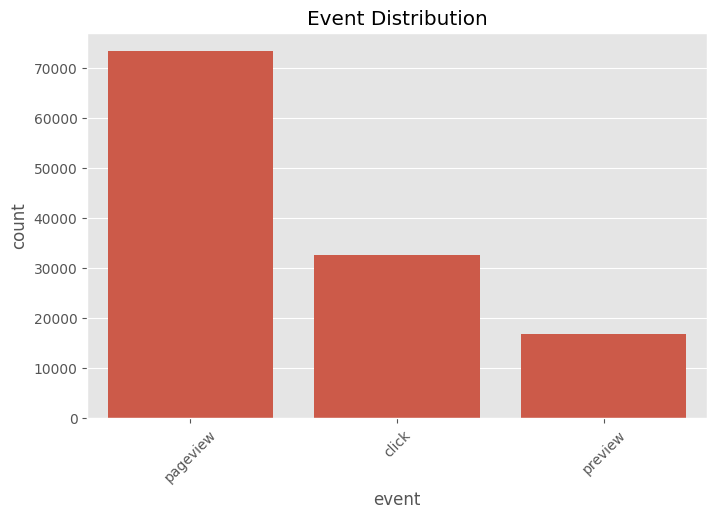

In [15]:
#visualization
plt.figure(figsize=(8,5))

sns.countplot(
    x='event',
    data=df,
    order=df['event'].value_counts().index
)

plt.title("Event Distribution")
plt.xticks(rotation=45)
plt.show()

***3.top contries and visualization***

In [16]:
top_countries = df['country'].value_counts().head(10)

print(top_countries)

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64


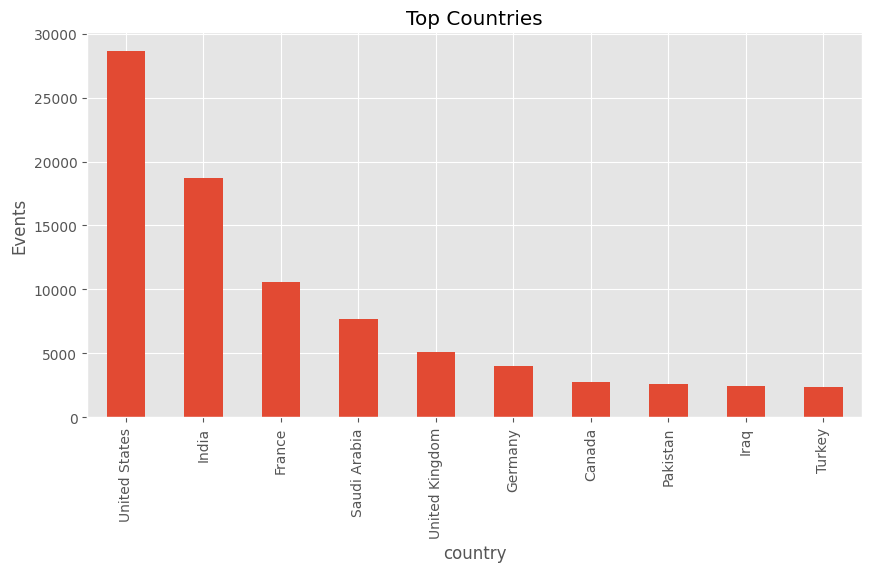

In [17]:
#visualization
top_countries.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Countries")
plt.ylabel("Events")
plt.show()

***4. top cities and visualization***

In [18]:
top_cities = df['city'].value_counts().head(10)

print(top_cities)

city
Unknown        8802
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64


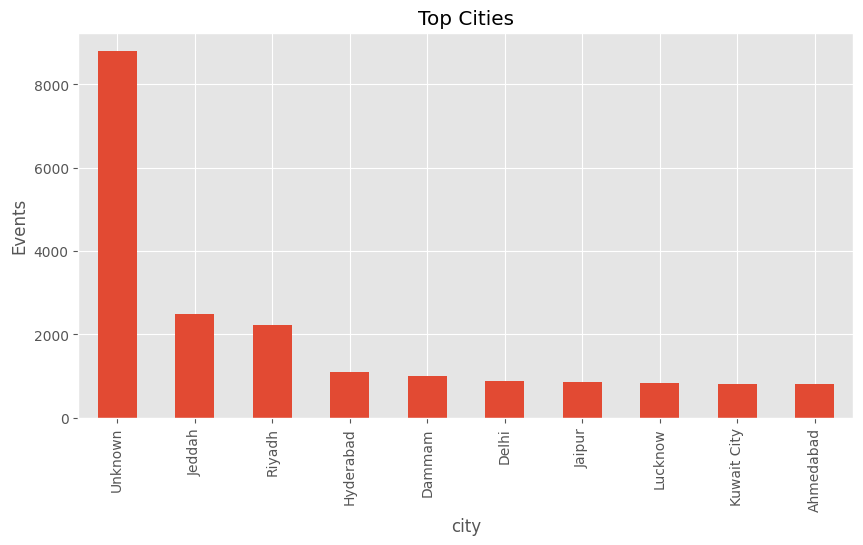

In [19]:
#visualization
top_cities.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Cities")
plt.ylabel("Events")
plt.show()

***5. popular artists and visualization***

In [20]:
top_artists = df['artist'].value_counts().head(10)

print(top_artists)

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64


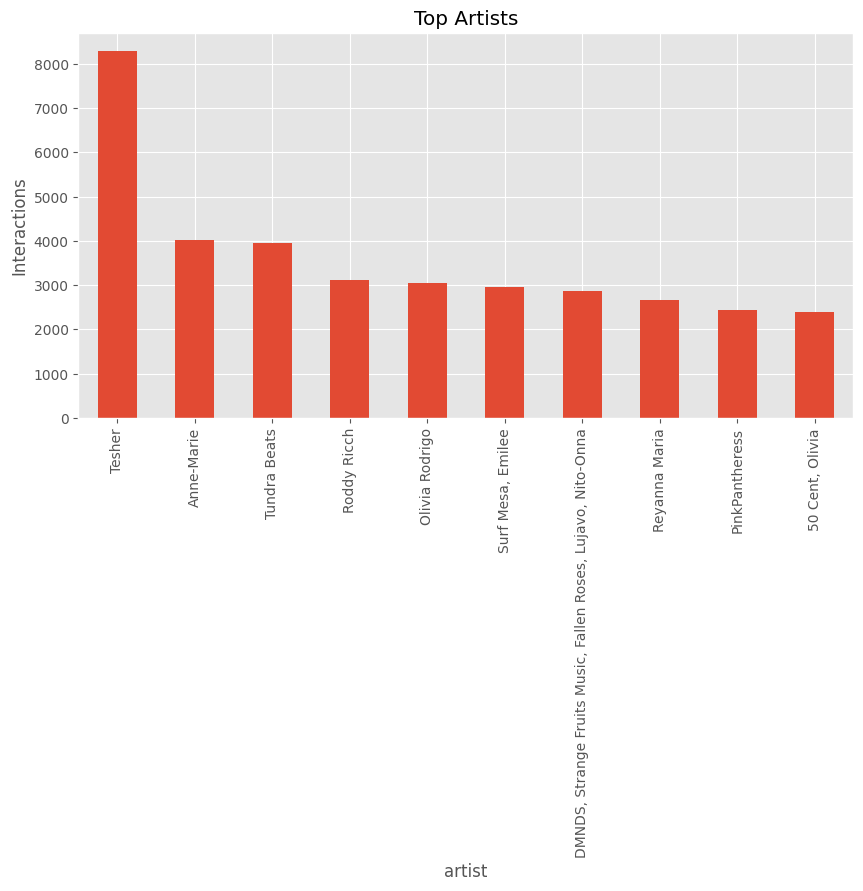

In [21]:
#visualization
top_artists.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Artists")
plt.ylabel("Interactions")
plt.show()

***6. popular albums and visualization***

In [22]:
top_albums = df['album'].value_counts().head(10)

print(top_albums)

album
Jalebi Baby                             8288
Beautiful                               4028
Beautiful Day                           3950
Late At Night                           3059
ily (i love you baby) (feat. Emilee)    2956
SOUR                                    2878
The Massacre                            2870
Calabria (feat. Lujavo & Nito-Onna)     2865
So Pretty                               2830
Summer Of Love                          2108
Name: count, dtype: int64


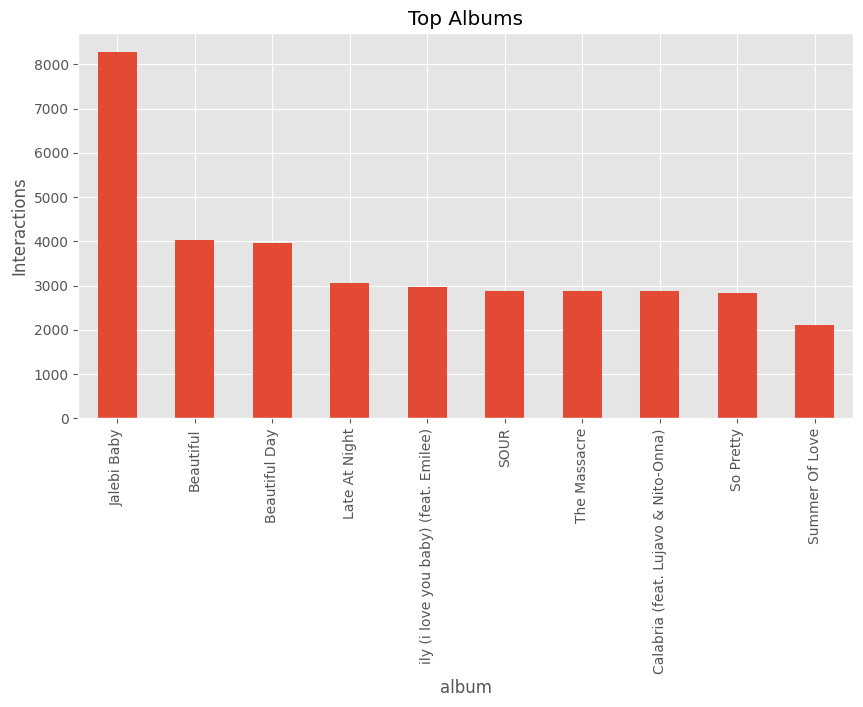

In [23]:
#visualization
top_albums.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Albums")
plt.ylabel("Interactions")
plt.show()

***7. popular tracks and visualization***

In [24]:
top_tracks = df['track'].value_counts().head(10)

print(top_tracks)

track
Jalebi Baby                              8288
Beautiful                                4037
Beautiful Day                            3951
Late At Night                            3059
ily (i love you baby) (feat. Emilee)     2956
Calabria (feat. Lujavo & Nito-Onna)      2865
So Pretty                                2830
Candy Shop                               2397
Summer of Love (Shawn Mendes & Tainy)    2108
Build a Bitch                            2072
Name: count, dtype: int64


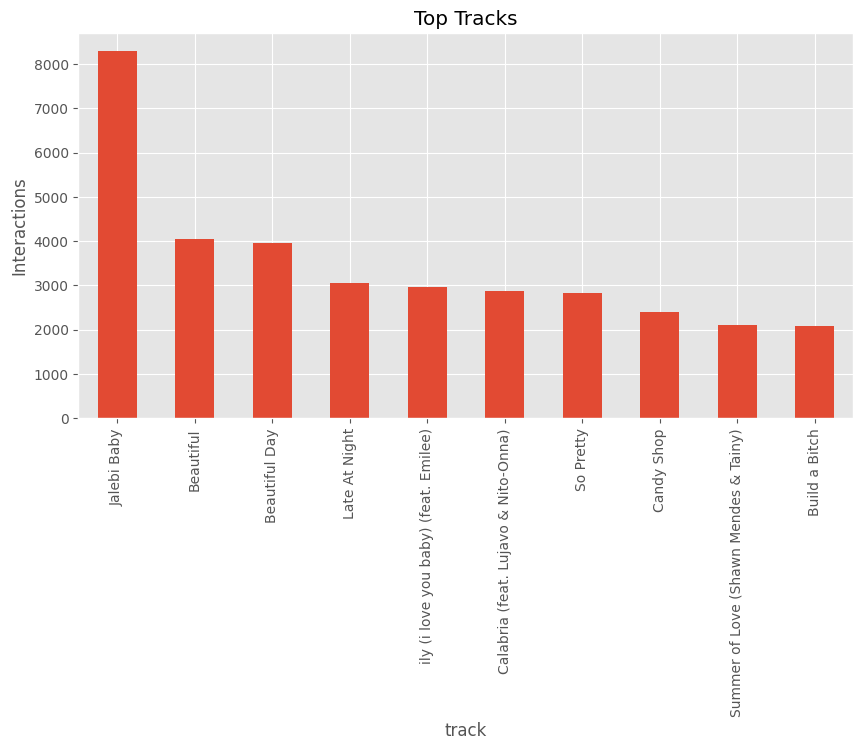

In [25]:
#visualization
top_tracks.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Tracks")
plt.ylabel("Interactions")
plt.show()

In [26]:
daily_traffic = df.groupby(
    df['date'].dt.date
).size()

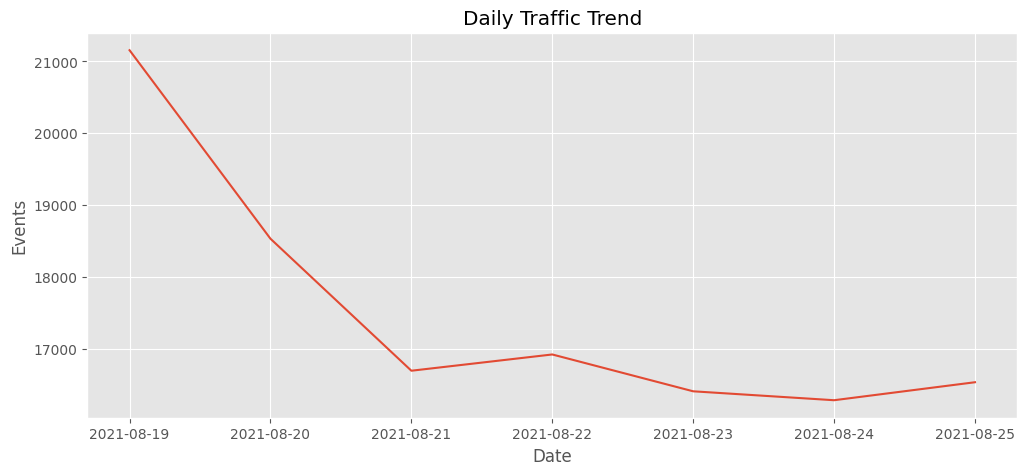

In [27]:
plt.figure(figsize=(12,5))

daily_traffic.plot()

plt.title("Daily Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Events")
plt.show()

***8. country wise event analysis***

In [28]:
country_event = pd.crosstab(
    df['country'],
    df['event']
)

country_event.head()

event,click,pageview,preview
country,,,
Afghanistan,0,2,0
Albania,58,231,58
Algeria,96,328,91
American Samoa,1,3,0
Andorra,0,2,1


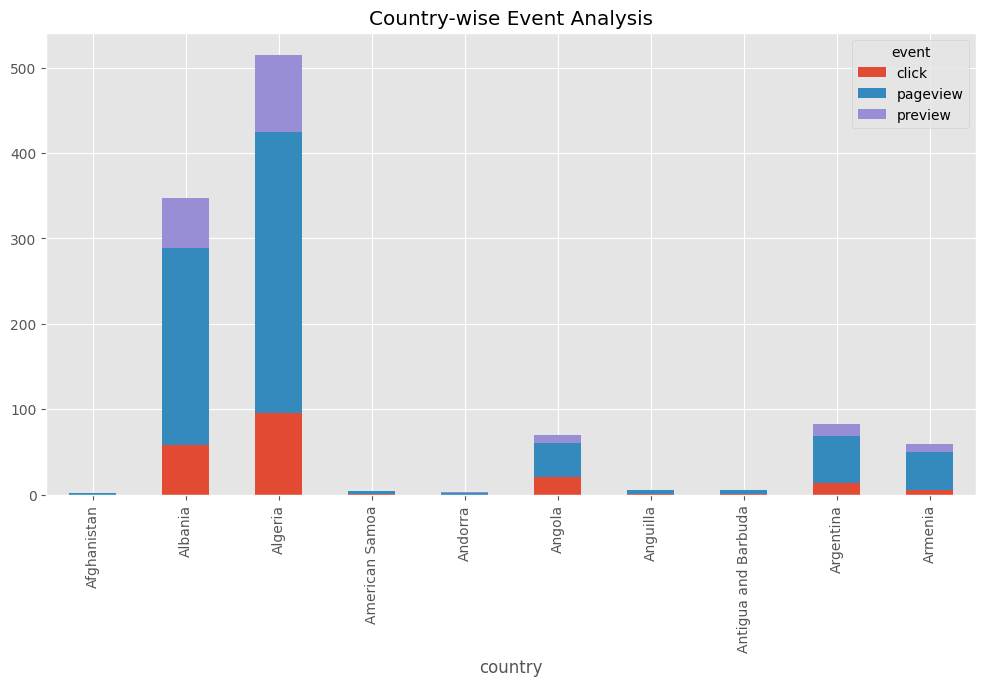

In [29]:
#visualization
country_event.head(10).plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Country-wise Event Analysis")
plt.show()

In [30]:
#artist engagement analysis
artist_event = pd.crosstab(
    df['artist'],
    df['event']
)

artist_event.head(10)

event,click,pageview,preview
artist,,,
$Mar,0,1,0
$NOT,3,5,1
$hyfromdatre,1,1,0
$krrt Cobain,0,1,0
$ofaygo,2,5,0
$uicideboy$,2,6,0
*GLITCH,0,1,0
03 Greedo,0,2,0
1 King,1,3,0


**top link id's**

In [31]:
top_links = df['linkid'].value_counts().head(10)

print(top_links)

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
23199824-9cf5-4b98-942a-34965c3b0cc2    2675
c2c876ab-b093-4750-9449-6b4913da6af3    2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd    2390
d5317591-872a-487d-87cb-10a516643d5f    2074
a107c329-5d35-4c7d-8050-50bc69ce7dbc    2072
Name: count, dtype: int64


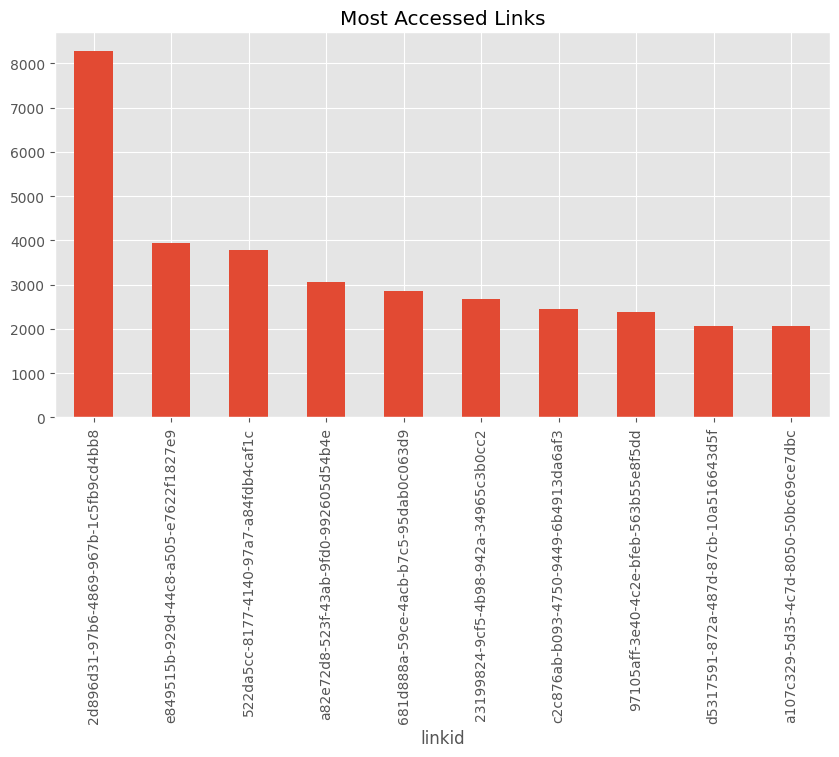

In [32]:
#visualization
top_links.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Most Accessed Links")
plt.show()

**RECOMMENDATIONS**


1. Focus on High-Traffic Regions

The majority of user activity is concentrated in a few countries and cities. Marketing campaigns and promotional activities should be targeted toward these high-performing regions to maximize user engagement and reach.

2. Promote Popular Content

The most frequently accessed artists, albums, and tracks indicate user preferences. Similar content can be recommended to users, and popular content can be highlighted on the platform to increase engagement.

3. Improve Engagement in Low-Performing Regions

Countries and cities with lower activity levels should be targeted through localized marketing campaigns, advertisements, and region-specific content recommendations.

4. Optimize Frequently Accessed Links

The most visited link IDs represent content with high user interest. These links should be optimized for faster loading times, better user experience, and stronger call-to-action elements.

**CONCLUSION**


This Website Traffic Analysis project successfully examined user interaction data using event logs, geographical information, content details, and link activity. The analysis identified key traffic patterns, including the most active countries and cities, popular artists and tracks, and the most frequently accessed content links.

Visualizations provided valuable insights into user behavior, content popularity, and traffic trends over time. The findings indicate that user engagement is driven by a limited set of highly popular content and concentrated geographical regions.